# Independent Route-3 7D Held-out Recovery, Coverage, SBC, and PPC

This notebook applies the immutable criteria to 256 new held-out seven-parameter
theta values and new simulator seeds. Every case receives 4,096 equal-mixture
posterior samples. Synthetic PPC uses 32 fixed-random and 32 disjoint
worst-recovery cases. `c_ctx2th` is fixed, not inferred, and receives no
posterior or recovery metric.

Even a GO would concern only conditional recovery in synthetic cortical-rate
space. Real-EEG inference remains NO-GO without an independently validated
cortical-source-to-Fpz-Cz measurement model.

In [1]:
from __future__ import annotations
from datetime import datetime, timezone
import importlib.metadata as mdist
import json
import os
from pathlib import Path
import platform
import sys

import matplotlib.pyplot as plt
import nbformat
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "S4_sbi" / "src").exists():
    for parent in PROJECT_ROOT.parents:
        if (parent / "S4_sbi" / "src").exists():
            PROJECT_ROOT = parent
            break
for value in (PROJECT_ROOT / "S4_sbi" / "src", PROJECT_ROOT):
    if str(value) not in sys.path:
        sys.path.insert(0, str(value))

environment = {
    "executed_utc": datetime.now(timezone.utc).isoformat(),
    "conda_environment": os.environ.get("CONDA_DEFAULT_ENV"),
    "sys.executable": sys.executable,
    "sys.prefix": sys.prefix,
    "python": platform.python_version(),
    "kernel_id": "neurolib",
    "kernel_display_name": "Python (neurolib)",
    "numpy": mdist.version("numpy"),
    "torch": mdist.version("torch"),
    "sbi": mdist.version("sbi"),
    "neurolib": mdist.version("neurolib"),
}
assert Path(sys.prefix).name.lower() == "neurolib"
display(pd.DataFrame(environment.items(), columns=["item", "value"]))

,item,value
0,executed_utc,2026-07-28T00:51:04.798084+00:00
1,conda_environment,neurolib
2,sys.executable,C:\Users\YUS190\AppData\Local\anaconda3\envs\n...
3,sys.prefix,C:\Users\YUS190\AppData\Local\anaconda3\envs\n...
4,python,3.10.20
5,kernel_id,neurolib
6,kernel_display_name,Python (neurolib)
7,numpy,2.2.6
8,torch,2.5.1
9,sbi,0.26.1


In [2]:
from sleep_sbi.route3_7d_experiment import *
from sleep_sbi.route3_7d_validation import *

print("Preregistration SHA-256:", verify_preregistration())
print("Held-out criteria SHA-256:", verify_heldout_criteria())
heldout = run_heldout_256(max_workers=6)
display(pd.DataFrame([heldout["manifest"]]))
independence = audit_independence_from_8d()
display(pd.DataFrame([independence["summary"]]))

Preregistration SHA-256: 2cedb6a68de307ab2f9233b4009a8f58854316259b6c185aeb61af5efdcbc363
Held-out criteria SHA-256: 49a4f9590466a6d9ba83f83ee5b6783e268ba996f8e8fc7328e261fb0405edee


,attempted,success,failed,failure_rate,sum_simulator_runtime_s,median_runtime_s,exact_training_theta_duplicates,training_simulator_seed_overlaps,fixed_c_ctx2th,preregistration_hash,heldout_criteria_hash
0,256,256,0,0.0,1467.729443,5.642976,0,0,0.125349,2cedb6a68de307ab2f9233b4009a8f58854316259b6c18...,49a4f9590466a6d9ba83f83ee5b6783e268ba996f8e8fc...


,new_rows,old_rows,full_8d_exact_duplicate_new_rows,free_7d_exact_duplicate_new_rows,simulator_seed_intersection_count,nearest_7d_prior_rms_distance_min,nearest_7d_prior_rms_distance_median,nearest_7d_prior_rms_distance_q05,descriptive_count_below_0p01,descriptive_count_below_0p05,near_neighbor_thresholds_are_exclusion_rules,samples_removed_after_audit
0,4352,2176,0,0,0,0.034281,0.102245,0.067588,0,31,False,0


## Posterior sampling and parameter recovery

Errors are normalized by prior width. The prior-median baseline predicts 0.5
for every normalized parameter. Positive improvement means the ensemble median
beats this baseline. Rank correlation measures ordering, not calibration.

,parameter,prior_median_mae,posterior_median_mae,posterior_median_rmse,posterior_mean_mae,mae_improvement_fraction,rank_correlation,median_90_ci_width,median_80_ci_width,median_50_ci_width,boundary_sample_fraction
0,mue,0.25,0.146667,0.181475,0.147011,0.413333,0.773652,0.506150,0.416622,0.231663,0.011132
1,mui,0.25,0.004890,0.010166,0.005053,0.980439,0.999356,0.016667,0.012968,0.006778,0.020404
2,b,0.25,0.087927,0.121551,0.089298,0.648293,0.907693,0.311591,0.244693,0.130514,0.009633
3,tauA,0.25,0.186293,0.228416,0.185841,0.254826,0.592679,0.660072,0.542407,0.301392,0.010716
4,g_LK,0.25,0.151165,0.205420,0.152080,0.395340,0.693230,0.498563,0.416298,0.223838,0.009151
5,g_h,0.25,0.125562,0.165088,0.126145,0.497753,0.822371,0.415502,0.315879,0.162453,0.009034
6,c_th2ctx,0.25,0.145323,0.185559,0.147201,0.418707,0.767824,0.503505,0.396984,0.212273,0.011350


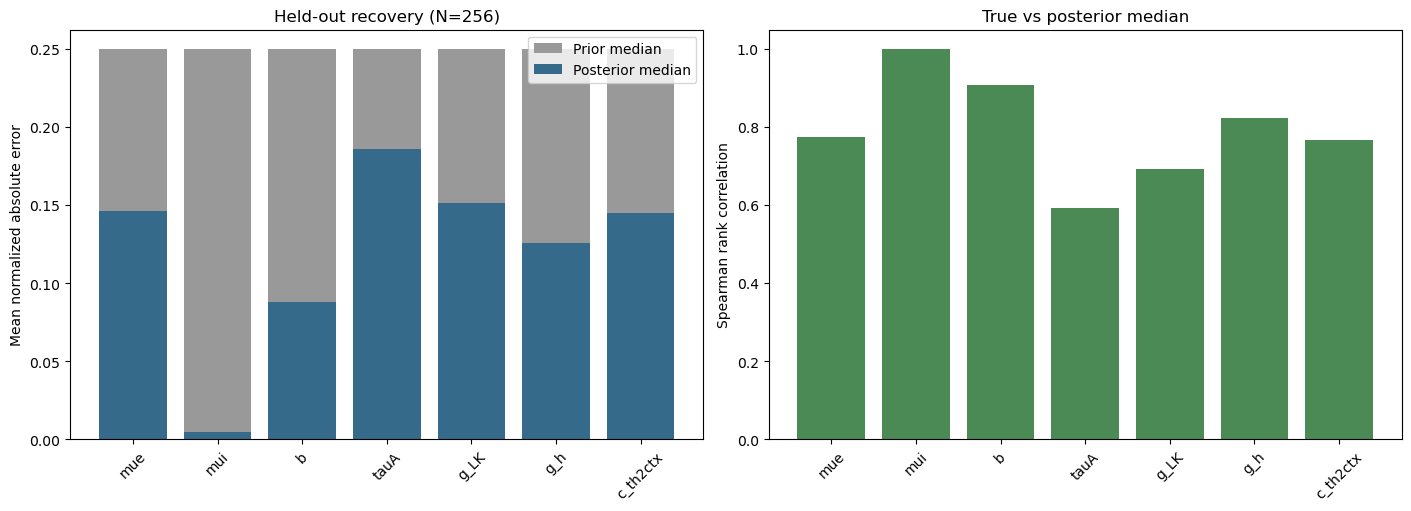

In [3]:
posterior = sample_heldout_posteriors(heldout["path"])
recovery = analyze_recovery_coverage(posterior["path"])
display(recovery["recovery"])

fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)
table = recovery["recovery"]
axes[0].bar(table.parameter, table.prior_median_mae, label="Prior median", color="#999999")
axes[0].bar(table.parameter, table.posterior_median_mae, label="Posterior median", color="#356a8a")
axes[0].tick_params(axis="x", rotation=45)
axes[0].set(ylabel="Mean normalized absolute error", title="Held-out recovery (N=256)")
axes[0].legend()
axes[1].bar(table.parameter, table.rank_correlation, color="#4c8a55")
axes[1].tick_params(axis="x", rotation=45)
axes[1].set(ylabel="Spearman rank correlation", title="True vs posterior median")
figure_dir = HELDOUT_ROOT / "figures"; figure_dir.mkdir(parents=True, exist_ok=True)
fig.savefig(figure_dir / "recovery_summary.png", dpi=180)
fig.savefig(figure_dir / "recovery_summary.svg")
plt.show()

## Coverage and SBC

Coverage is accompanied by Wilson 95% intervals for 256 cases. Formal
compatibility requires nominal 80% and 90% levels to lie inside the interval.
SBC histograms are interpreted jointly with error, contraction, and coverage;
a single p-value is never used as the verdict.

,estimator,parameter,nominal_level,covered,n,empirical_coverage,wilson_95_low,wilson_95_high,nominal_inside_wilson,severe_undercoverage
0,ensemble,mue,0.5,101,256,0.394531,0.336643,0.455537,False,False
1,ensemble,mue,0.8,172,256,0.671875,0.612188,0.726480,False,False
2,ensemble,mue,0.9,208,256,0.812500,0.760198,0.855562,False,False
3,ensemble,mui,0.5,165,256,0.644531,0.584156,0.700633,False,False
4,ensemble,mui,0.8,231,256,0.902344,0.859815,0.932976,False,False
5,ensemble,mui,0.9,249,256,0.972656,0.944644,0.986693,False,False
6,ensemble,b,0.5,121,256,0.472656,0.412356,0.533765,True,False
7,ensemble,b,0.8,191,256,0.746094,0.689410,0.795501,False,False
8,ensemble,b,0.9,223,256,0.871094,0.824496,0.906719,True,False
9,ensemble,tauA,0.5,107,256,0.417969,0.359199,0.479164,False,False


,estimator,parameter,rank_mean,rank_std,chi_square_10bin,chi_square_p_value,bin_0,bin_1,bin_2,bin_3,bin_4,bin_5,bin_6,bin_7,bin_8,bin_9
0,ensemble,mue,0.523277,0.324444,30.328125,3.857297e-04,39,21,18,23,18,22,21,20,29,45
1,ensemble,mui,0.422583,0.227479,58.687500,2.398264e-09,20,22,49,37,36,26,30,19,12,5
2,ensemble,b,0.533322,0.295655,18.140625,3.357665e-02,25,24,13,29,23,33,22,23,24,40
3,ensemble,tauA,0.506978,0.325914,32.828125,1.430724e-04,42,21,16,29,22,19,14,23,29,41
4,ensemble,g_LK,0.505585,0.322771,27.437500,1.183627e-03,42,21,26,17,20,16,17,32,31,34
5,ensemble,g_h,0.481927,0.319548,17.437500,4.228963e-02,35,31,27,24,22,20,12,22,29,34
6,ensemble,c_th2ctx,0.482363,0.328689,34.156250,8.386083e-05,37,39,24,16,20,20,17,18,23,42


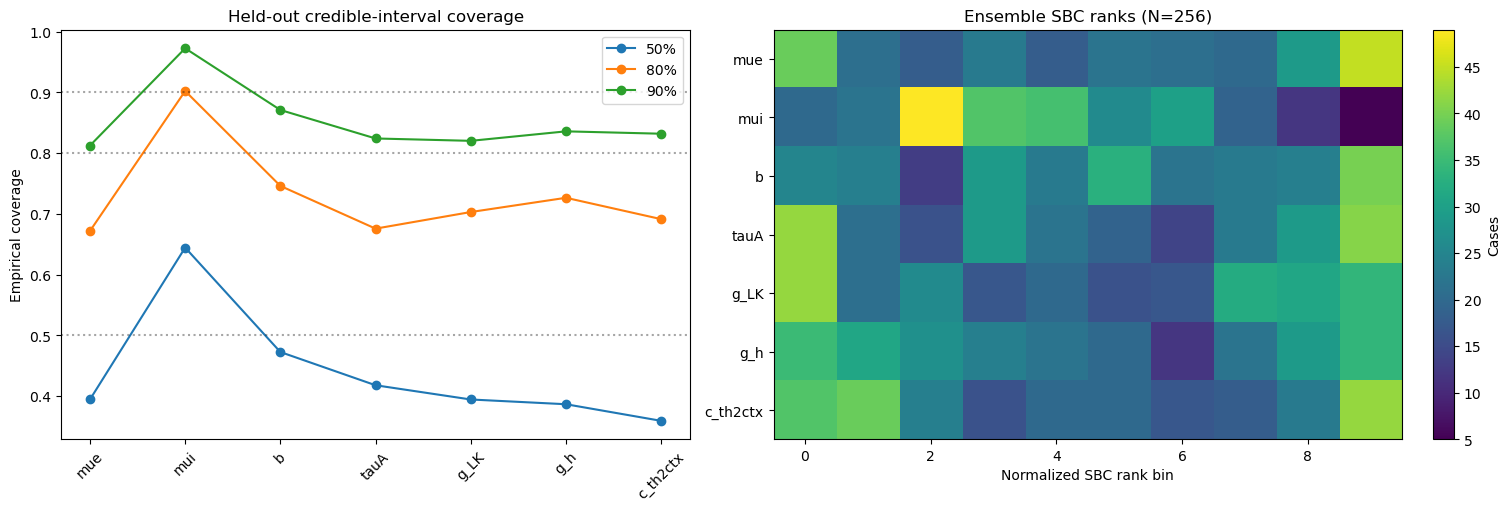

In [4]:
ensemble_coverage = recovery["coverage"].query("estimator == 'ensemble'")
display(ensemble_coverage)
display(recovery["sbc"].query("estimator == 'ensemble'"))

fig, axes = plt.subplots(1, 2, figsize=(15, 5), constrained_layout=True)
for level, frame in ensemble_coverage.groupby("nominal_level"):
    axes[0].plot(frame.parameter, frame.empirical_coverage, "o-", label=f"{level:.0%}")
    axes[0].axhline(level, color="black", ls=":", alpha=.35)
axes[0].tick_params(axis="x", rotation=45)
axes[0].set(ylabel="Empirical coverage", title="Held-out credible-interval coverage")
axes[0].legend()
sbc = recovery["sbc"].query("estimator == 'ensemble'")
image = axes[1].imshow(sbc[[f"bin_{i}" for i in range(10)]], aspect="auto", cmap="viridis")
axes[1].set_yticks(range(7), sbc.parameter)
axes[1].set(xlabel="Normalized SBC rank bin", title="Ensemble SBC ranks (N=256)")
fig.colorbar(image, ax=axes[1], label="Cases")
fig.savefig(figure_dir / "coverage_and_sbc.png", dpi=180)
fig.savefig(figure_dir / "coverage_and_sbc.svg")
plt.show()

## Preregistered 64-case synthetic PPC

For each selected held-out observation, 16 new posterior theta and 16 new prior
theta are simulated with independent seeds. Errors use the training-only
feature scale. PPC improvement does not override undercoverage or false
posterior contraction.

,feature,posterior_predictive_median_scaled_abs_error,prior_predictive_median_scaled_abs_error,improvement_fraction,posterior_better
0,r_exc_mean_hz,0.032615,0.612643,0.946763,True
1,r_exc_std_hz,0.045399,0.648877,0.930035,True
2,r_exc_relative_so_power,0.109749,0.586397,0.812842,True
3,r_exc_relative_sigma_power,0.243728,0.694076,0.648845,True
4,r_exc_so_peak_frequency_hz,0.000000,0.500000,1.000000,True
5,r_exc_sigma_peak_frequency_hz,0.250000,0.437500,0.428571,True
6,r_exc_spectral_entropy_0p5_20,0.102288,0.612940,0.833119,True
7,r_inh_mean_hz,0.023920,0.630306,0.962050,True
8,r_inh_std_hz,0.045698,0.638789,0.928462,True
9,r_inh_relative_so_power,0.101818,0.518046,0.803458,True


,cases,random_cases,worst_cases,posterior_draws_per_case,posterior_predictive_attempted,posterior_predictive_failed,prior_predictive_attempted,prior_predictive_failed,features_posterior_better,overall_posterior_scaled_error,overall_prior_scaled_error,overall_improvement_fraction
0,64,32,32,16,1024,0,1024,0,14,0.099643,0.595078,0.832555


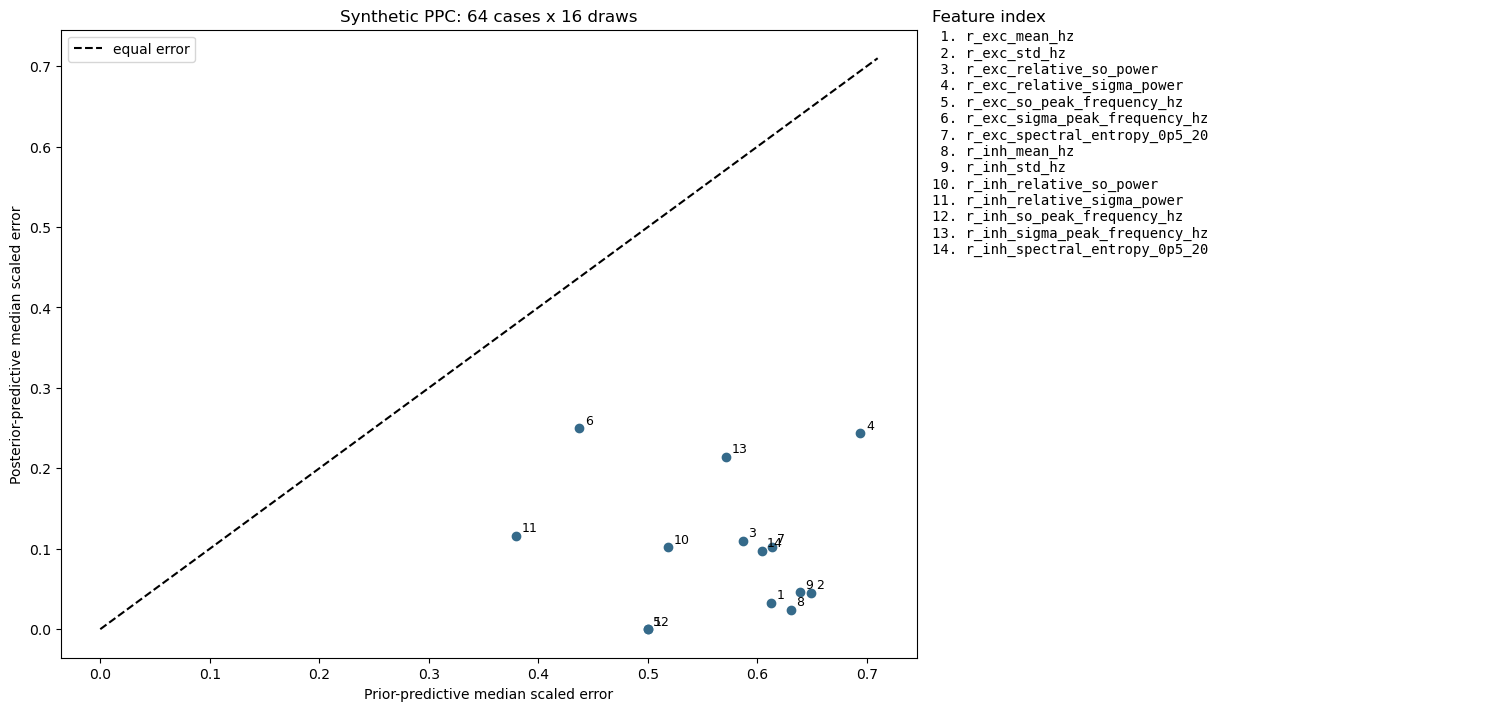

In [5]:
ppc = run_ppc_64(recovery, heldout["path"], max_workers=6)
display(ppc["metrics"])
display(pd.DataFrame([ppc["summary"]]))

fig, (ax, label_ax) = plt.subplots(
    1, 2, figsize=(15, 7), constrained_layout=True,
    gridspec_kw={"width_ratios": [3, 2]},
)
ax.scatter(
    ppc["metrics"].prior_predictive_median_scaled_abs_error,
    ppc["metrics"].posterior_predictive_median_scaled_abs_error,
    color="#356a8a",
)
limit = max(ax.get_xlim()[1], ax.get_ylim()[1])
ax.plot([0, limit], [0, limit], "k--", label="equal error")
for index, row in ppc["metrics"].reset_index(drop=True).iterrows():
    ax.annotate(
        str(index + 1),
        (row.prior_predictive_median_scaled_abs_error, row.posterior_predictive_median_scaled_abs_error),
        fontsize=9, xytext=(4, 3), textcoords="offset points",
    )
ax.set(xlabel="Prior-predictive median scaled error", ylabel="Posterior-predictive median scaled error", title="Synthetic PPC: 64 cases x 16 draws")
ax.legend()
label_ax.axis("off")
label_ax.set_title("Feature index", loc="left")
label_ax.text(
    0, 1,
    "\n".join(f"{index + 1:>2}. {name}" for index, name in enumerate(ppc["metrics"].feature)),
    va="top", ha="left", family="monospace", fontsize=10,
)
fig.savefig(figure_dir / "synthetic_ppc.png", dpi=180)
fig.savefig(figure_dir / "synthetic_ppc.svg")
plt.show()

## Immutable automatic decision

No threshold, feature, fixed value, network, sample, or held-out case is changed
after these results. The output is exactly one of GO, CONDITIONAL GO, or NO-GO.
The decision never unlocks real-EEG inference.

In [6]:
decision = evaluate_decision(recovery, ppc)
display(pd.DataFrame(decision["checks"].items(), columns=["check", "value"]))
print("FINAL ROUTE-3 7D DECISION:", decision["decision"])
assert decision["decision"] in {"GO", "CONDITIONAL GO", "NO-GO"}
assert not decision["real_eeg_inference_unlocked"]

,check,value
0,preflight_engineering_gate,True
1,training_failure_gate,True
2,heldout_failure_gate,True
3,posterior_finite_support_rate,1.0
4,posterior_finite_support_gate,True
5,prior_level_unrecoverable_parameter_count,0
6,prior_level_unrecoverable_gate,True
7,systematically_worse_parameter_count,0
8,systematic_worsening_gate,True
9,better_than_prior_parameter_count,7


FINAL ROUTE-3 7D DECISION: NO-GO
